Epoch    0 | Train Huber Loss: 3.3171 | Test MSE: 20.0595
Epoch  300 | Train Huber Loss: 1.9081 | Test MSE: 12.1905
Epoch  600 | Train Huber Loss: 1.8795 | Test MSE: 12.1835
Epoch  900 | Train Huber Loss: 1.8360 | Test MSE: 12.1504
Epoch 1200 | Train Huber Loss: 1.8088 | Test MSE: 12.1791


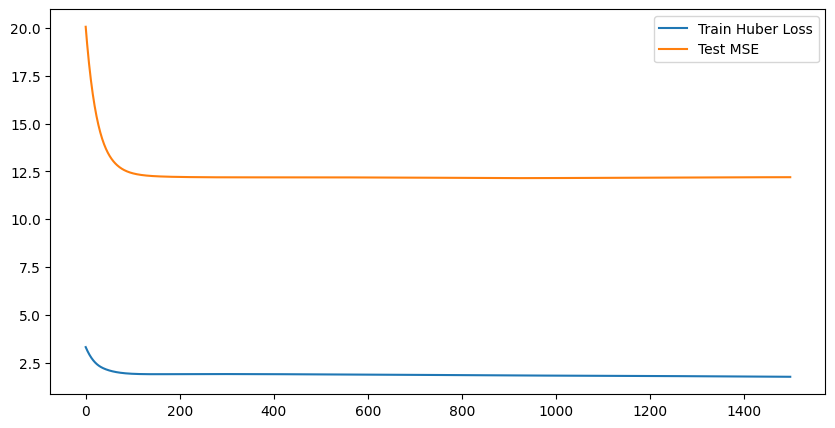

Kullanıcı 0 için Film 16 tahmini: 0.78


In [12]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv('/content/drive/MyDrive/ratings_long.csv')
num_users, num_movies, latent_factors = 20, 1000, 8

train_df = df.sample(frac=0.8, random_state=42)
test_df = df.drop(train_df.index)

def create_matrix(data):
    matrix = np.full((num_users, num_movies), np.nan)
    for rec in data.itertuples():
        if rec.userId < num_users and rec.movieId < num_movies:
            matrix[rec.userId, rec.movieId] = rec.rating
    return torch.tensor(matrix, dtype=torch.float32)

R_train = create_matrix(train_df)
R_test = create_matrix(test_df)
mask_train = ~torch.isnan(R_train)
mask_test = ~torch.isnan(R_test)

u = torch.randn(num_users, latent_factors, requires_grad=True)
v = torch.randn(latent_factors, num_movies, requires_grad=True)
u_bias = torch.zeros(num_users, requires_grad=True)
v_bias = torch.zeros(num_movies, requires_grad=True)


optimizer = torch.optim.AdamW([u, v, u_bias, v_bias], lr=0.002, weight_decay=5.0)

def huber_loss(pred, target, delta=1.0):
    error = pred - target
    is_small_error = torch.abs(error) <= delta
    return torch.where(is_small_error, 0.5 * (error**2), delta * (torch.abs(error) - 0.5 * delta)).mean()

train_losses, test_losses = [], []

for epoch in range(1500):
    optimizer.zero_grad()
    prediction = torch.mm(u, v) + u_bias.unsqueeze(1) + v_bias
    loss = huber_loss(prediction[mask_train], R_train[mask_train])
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    with torch.no_grad():
        test_pred = torch.mm(u, v) + u_bias.unsqueeze(1) + v_bias
        test_loss = torch.nn.functional.mse_loss(test_pred[mask_test], R_test[mask_test])
        test_losses.append(test_loss.item())

    if epoch % 300 == 0:
        print(f"Epoch {epoch:4} | Train Huber Loss: {loss.item():.4f} | Test MSE: {test_loss.item():.4f}")

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Huber Loss')
plt.plot(test_losses, label='Test MSE')
plt.legend()
plt.show()

def tahmin_et(u_id, m_id):
    with torch.no_grad():
        return (torch.dot(u[u_id], v[:, m_id]) + u_bias[u_id] + v_bias[m_id]).item()

print(f"Kullanıcı 0 için Film 16 tahmini: {tahmin_et(0, 16):.2f}")